## Aim

In this code, we compute some metrics for one smaller area only: straightness, closeness centrality and betweeness centrality.

The computation of this metric will be done with the osmnx and momepy libraries. More information can be found [here](https://docs.momepy.org/en/stable/api/momepy.straightness_centrality.html#momepy.straightness_centrality).

In [1]:
from pathlib import Path

import geopandas as gpd
from matplotlib import pyplot as plt
import momepy
import osmnx as ox
import pandas as pd

Take a small network to test:

In [2]:
BASE_DIR = Path.cwd().parents[1]
print(BASE_DIR)

DATA_DIR = BASE_DIR / "data"
## IMAGES_DIR = BASE_DIR / "images"
PROCESSED_DIR = DATA_DIR / "processed"
## LOGS_DIR = BASE_DIR / "logs"

path_graphml = DATA_DIR / "graphml_bang" / "bangalore_graphml.graphml"

WARDS_GPKG_DIR = DATA_DIR / "gpkgs"
WARDS_G_DIR =  DATA_DIR / "g_files"

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad


In [3]:
## Detailed wards
df_inpath = PROCESSED_DIR / "bang_fix_mapshaper.shp"
print(df_inpath)

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\processed\bang_fix_mapshaper.shp


In [4]:
df = gpd.read_file(df_inpath)
df.head()

,ward_id,ward_name,Corporatio,geometry
0,25,25 - Vinayaka Layout,West,"POLYGON ((77.5033 12.95788, 77.50446 12.96083,..."
1,2,2 - Aerocity,North,"MULTIPOLYGON (((77.62561 13.10441, 77.62559 13..."
2,3,3 - Chowdeshwari ward,North,"POLYGON ((77.58519 13.13277, 77.58513 13.13262..."
3,15,15 - Ramamurthy Nagara,East,"POLYGON ((77.6749 13.01648, 77.67503 13.01647,..."
4,58,58 - Nagashettyhalli,North,"POLYGON ((77.57276 13.04724, 77.57339 13.04727..."


Load the previous downloaded graph and plot it:

In [5]:
filepath = WARDS_G_DIR /'25 - Vinayaka Layout.graphml'
G_ward = ox.load_graphml(filepath)

In [6]:
G_ward

In [7]:
# Plot the network once:

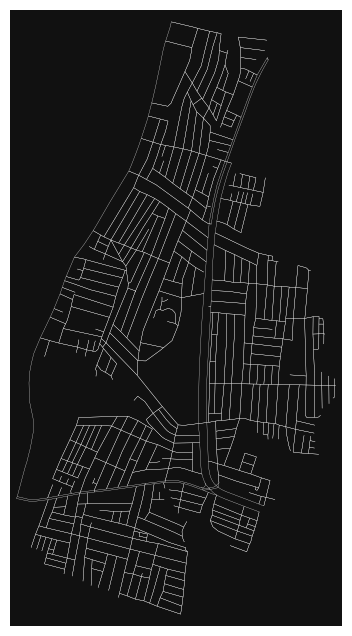

In [8]:
fig, ax = ox.plot_graph(G_ward, node_size=0, edge_color="w", edge_linewidth=0.2)

In [9]:
streets_graph = ox.projection.project_graph(G_ward)

In [10]:
edges = ox.graph_to_gdfs(
    ox.convert.to_undirected(streets_graph),
    nodes=False,
    edges=True,
    node_geometry=False,
    fill_edge_geometry=True,
)

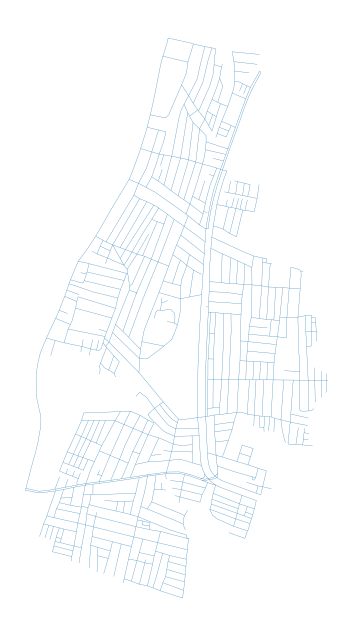

In [11]:
ax = edges.plot(linewidth=0.2, figsize=(8, 8))
ax.set_axis_off()

In [12]:
primal = momepy.gdf_to_nx(edges, approach="primal")

In [13]:
primal = momepy.straightness_centrality(primal)

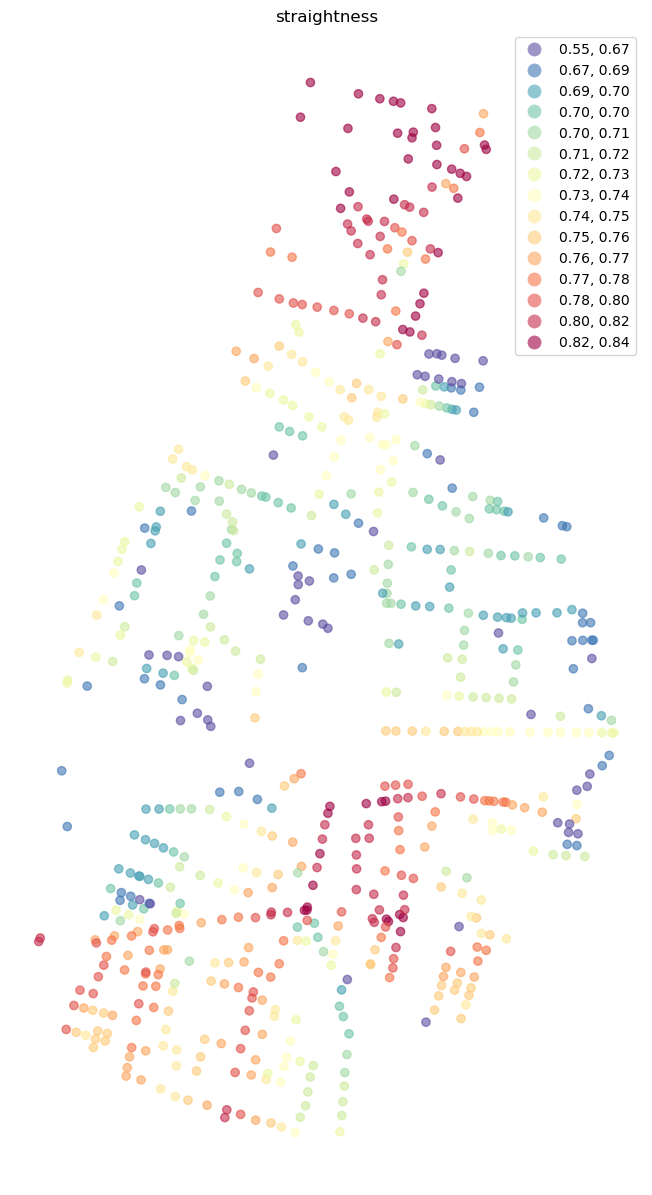

In [14]:
nodes = momepy.nx_to_gdf(primal, lines=False)
ax = nodes.plot(
    column="straightness",
    cmap="Spectral_r",
    scheme="quantiles",
    k=15,
    alpha=0.6,
    figsize=(15, 15),
    legend = True
)
ax.set_axis_off()
_ = ax.set_title("straightness")

In [15]:
nodes.shape

(682, 5)

Alternatively, we can also use the as a weight the length:

In [16]:
primal_weight = momepy.straightness_centrality(primal, weight = 'length')

Make the marker size smaller:

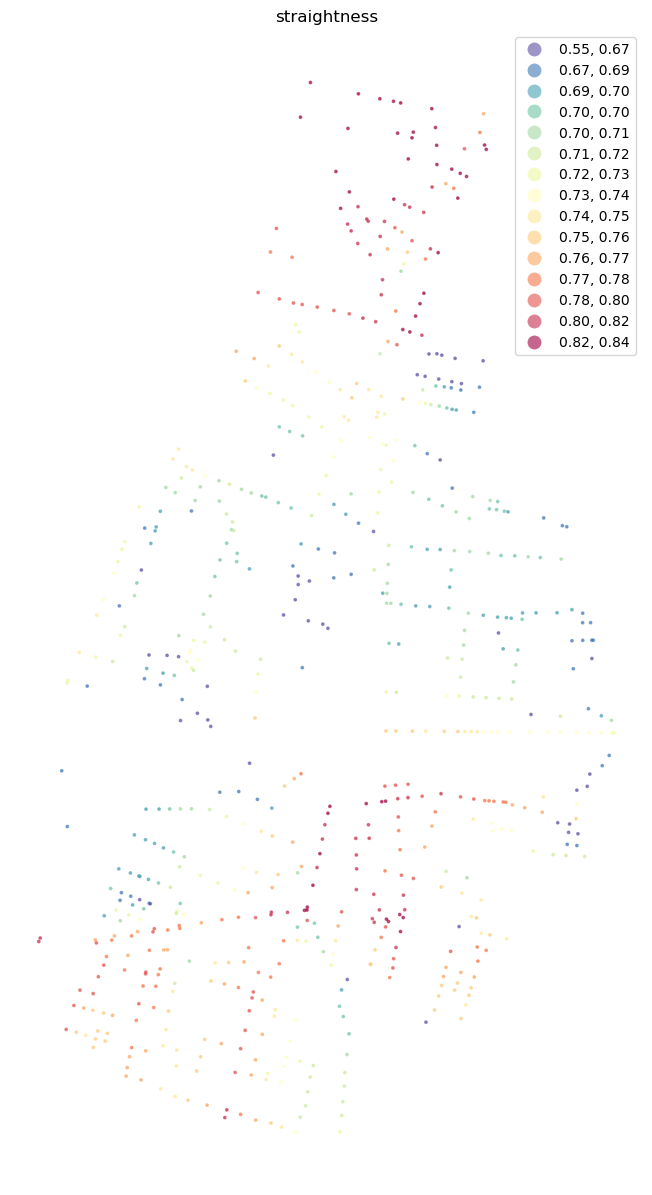

In [17]:
nodes = momepy.nx_to_gdf(primal_weight, lines=False)
ax = nodes.plot(
    column="straightness",
    cmap="Spectral_r",
    scheme="quantiles",
    k=15,
    alpha=0.6,
    markersize = 3,
    figsize=(15, 15),
    legend = True
)
ax.set_axis_off()
_ = ax.set_title("straightness")

Make a buffer around the node itself to compute the centrality:

In [18]:
primal_weight = momepy.straightness_centrality(
    primal,
    weight="length",
    radius=1000,      # meters
    distance="length"
)


  0%|          | 0/682 [00:00<?, ?it/s]

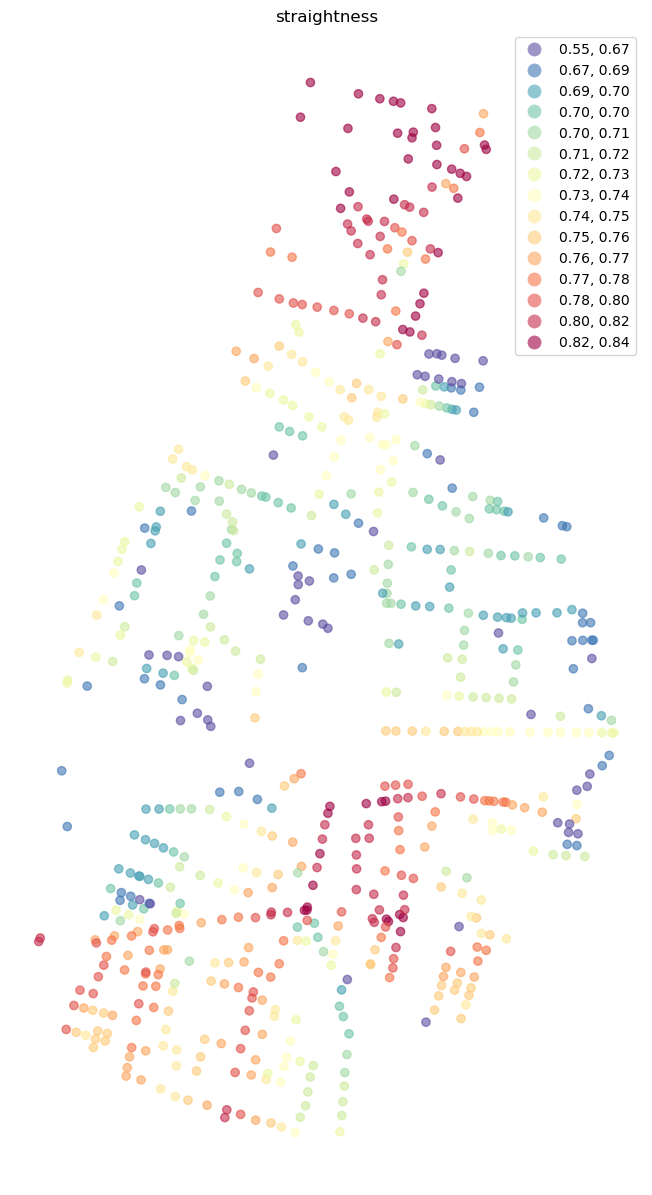

In [36]:
nodes = momepy.nx_to_gdf(primal, lines=False)
ax = nodes.plot(
    column="straightness",
    cmap="Spectral_r",
    scheme="quantiles",
    k=15,
    alpha=0.6,
    figsize=(15, 15),
    legend = True
)
ax.set_axis_off()
_ = ax.set_title("straightness")

In [ ]:
Compute the entire Bangalore network:

This takes fairly long to run and did not add any value add as such. Using internal setting only.

Example from the manual itself:

In [17]:
## https://docs.momepy.org/en/stable/user_guide/graph/centrality.html#Straightness
streets_graph = ox.graph_from_place(
    "Vicenza, Vicenza, Italy", network_type="drive"
)
streets_graph = ox.projection.project_graph(streets_graph)

In [16]:
edges = ox.graph_to_gdfs(
    ox.convert.to_undirected(streets_graph),
    nodes=False,
    edges=True,
    node_geometry=False,
    fill_edge_geometry=True,
)

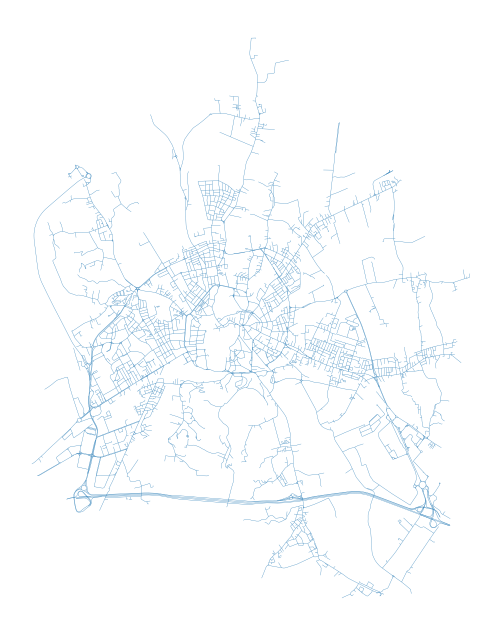

In [18]:
ax = edges.plot(linewidth=0.2, figsize=(8, 8))
ax.set_axis_off()

In [19]:
primal = momepy.gdf_to_nx(edges, approach="primal")

In [20]:
primal = momepy.straightness_centrality(primal)

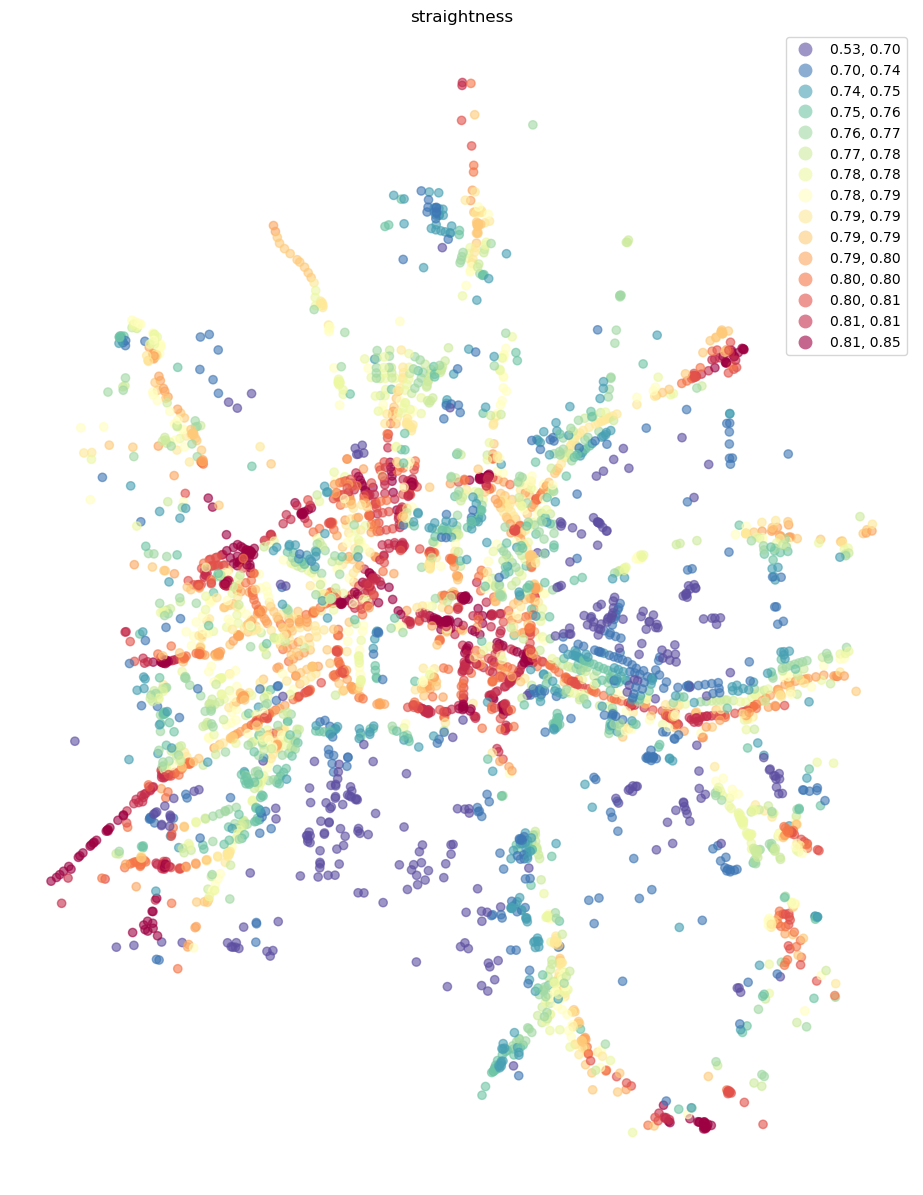

In [22]:
nodes = momepy.nx_to_gdf(primal, lines=False)
ax = nodes.plot(
    column="straightness",
    cmap="Spectral_r",
    scheme="quantiles",
    k=15,
    alpha=0.6,
    figsize=(15, 15),
    legend = True
)
ax.set_axis_off()
_ = ax.set_title("straightness")

In [23]:
nodes

,x,y,straightness,nodeID,geometry
0,696074.906244,5.043553e+06,0.654292,0,POINT (696074.906 5043552.635)
1,702954.316726,5.043159e+06,0.685890,1,POINT (702954.317 5043159.106)
2,695809.046030,5.043352e+06,0.733770,2,POINT (695809.046 5043351.54)
3,695519.624735,5.043520e+06,0.693828,3,POINT (695519.625 5043520.276)
4,703587.847624,5.042924e+06,0.762997,4,POINT (703587.848 5042924.349)
...,...,...,...,...,...
4262,697686.524727,5.047483e+06,0.745976,4262,POINT (697686.525 5047483.341)
4263,697791.633220,5.047517e+06,0.781866,4263,POINT (697791.633 5047516.976)
4264,697774.194648,5.047506e+06,0.773233,4264,POINT (697774.195 5047506.094)
4265,697792.404663,5.047510e+06,0.766323,4265,POINT (697792.405 5047510.117)


## Closeness centrality

There is global and local closeness. We try try both here: 

In [7]:
filepath = WARDS_G_DIR /'25 - Vinayaka Layout.graphml'
G_ward = ox.load_graphml(filepath)

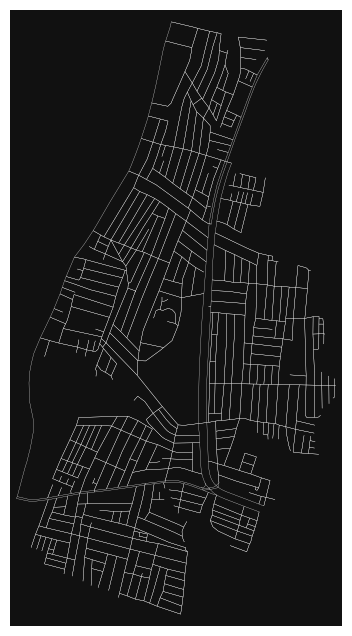

In [8]:
fig, ax = ox.plot_graph(G_ward, node_size=0, edge_color="w", edge_linewidth=0.2)

In [13]:
streets_graph = ox.projection.project_graph(G_ward)

In [15]:
edges = ox.graph_to_gdfs(
    ox.convert.to_undirected(streets_graph),
    nodes=False,
    edges=True,
    node_geometry=False,
    fill_edge_geometry=True,
)

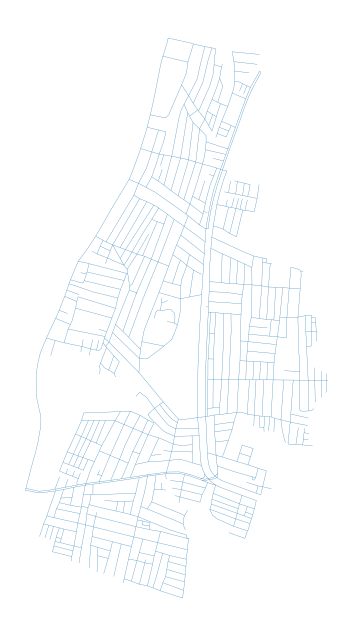

In [16]:
ax = edges.plot(linewidth=0.2, figsize=(8, 8))
ax.set_axis_off()

In [17]:
## https://docs.momepy.org/en/v0.7.2/user_guide/graph/centrality
primal = momepy.gdf_to_nx(edges, approach='primal')

In [18]:
primal = momepy.closeness_centrality(primal, radius=1000, name='closeness400', distance='mm_len', weight='mm_len')

  0%|          | 0/682 [00:00<?, ?it/s]

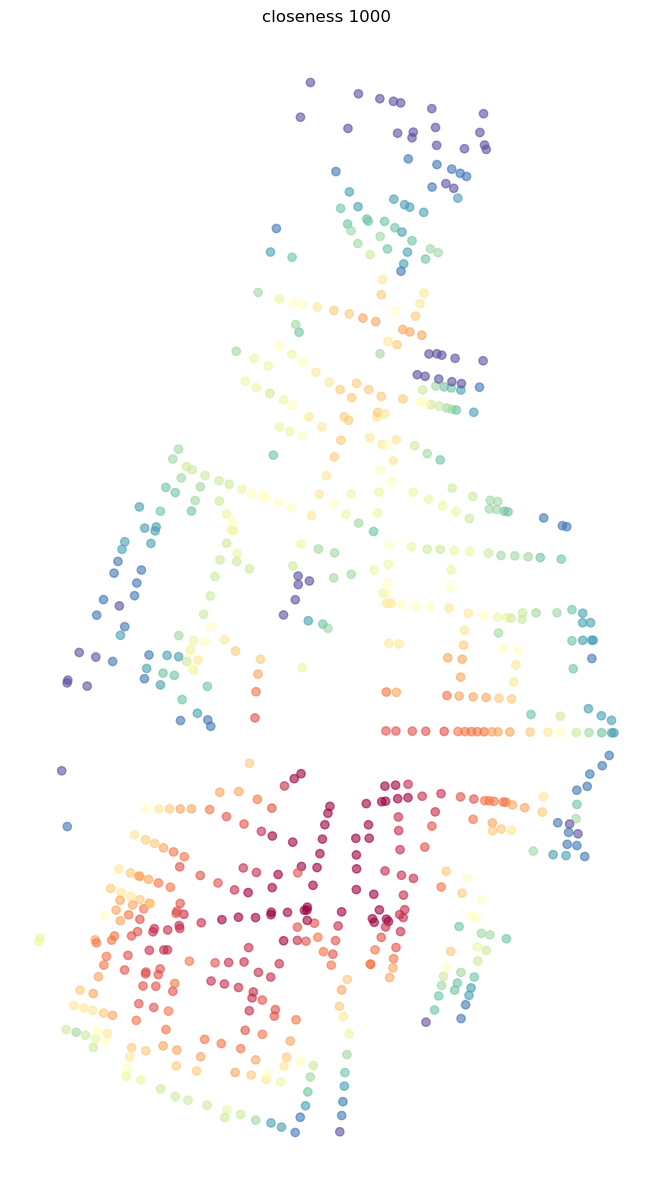

In [21]:
nodes = momepy.nx_to_gdf(primal, lines=False)
f, ax = plt.subplots(figsize=(15, 15))
nodes.plot(ax=ax, column='closeness400', cmap='Spectral_r', scheme='quantiles', k=15, alpha=0.6)
ax.set_axis_off()
ax.set_title('closeness 1000')
plt.show()

In [24]:
primal = momepy.closeness_centrality(primal, name='closeness_global', weight='mm_len')

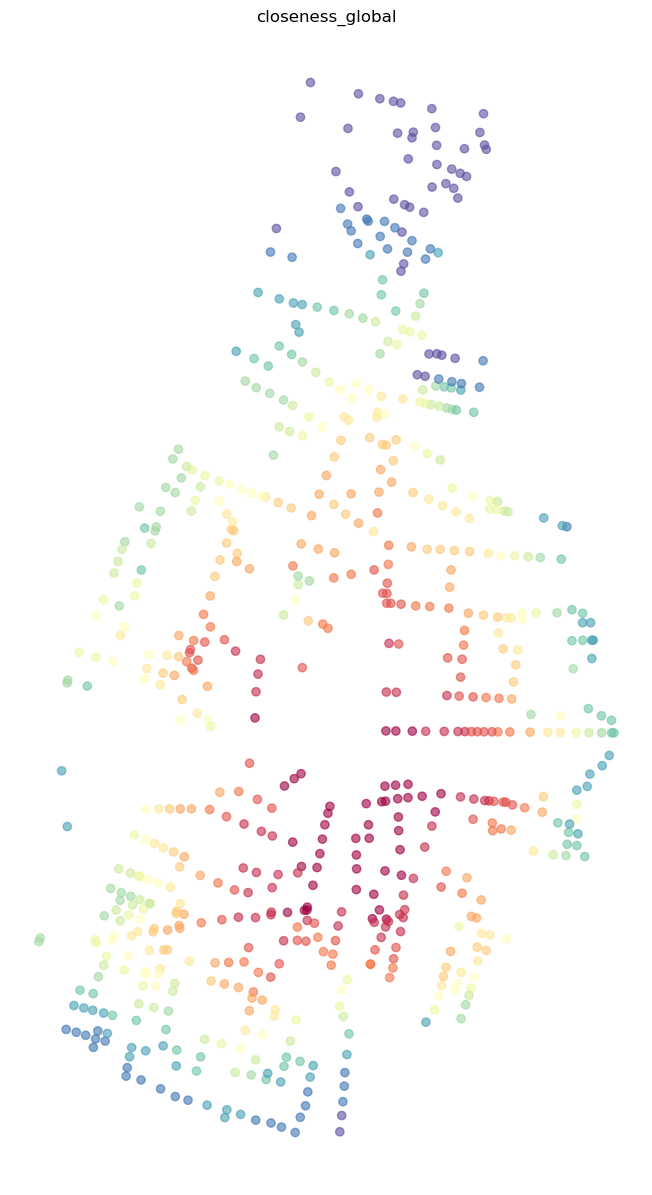

In [26]:
## This runs faster
nodes = momepy.nx_to_gdf(primal, lines=False)
f, ax = plt.subplots(figsize=(15, 15))
nodes.plot(ax=ax, column='closeness_global', cmap='Spectral_r', scheme='quantiles', k=15, alpha=0.6)
ax.set_axis_off()
ax.set_title('closeness_global')
plt.show()

In [19]:
path_graphml_bang = DATA_DIR / "graphml_bang" / "bangalore_graphml.graphml"

In [20]:
G = ox.io.load_graphml(filepath)

In [21]:
G.graph["crs"]

'epsg:4326'

In [22]:
df.crs.to_epsg()

4326

## References 

Boeing, G. (2025). Modeling and Analyzing Urban Networks and Amenities With OSMnx. Geographical Analysis 57, no. 4: 567577. https://doi.org/10.1111/gean.70009.

Fleischmann, M. (2019) ‘momepy: Urban Morphology Measuring Toolkit’, Journal of Open Source Software, 4(43), p. 1807. doi: 10.21105/joss.01807.

https://docs.momepy.org/en/stable/api/momepy.straightness_centrality.html#momepy.straightness_centrality